# Parameters

In [1]:
import os
os.environ['OMP_NUM_THREADS'] = '1'
os.environ['MKL_NUM_THREADS'] = '1'
os.environ['OPENBLAS_NUM_THREADS'] = '1'
os.environ['KMP_DUPLICATE_LIB_OK'] = 'TRUE'

In [2]:
import sys
from pathlib import Path
import pandas as pd

# ===== CONFIGURAÇÃO DE CAMINHOS =====
current_notebook = Path.cwd()  
project_root = current_notebook.parent.parent 

# Adiciona o diretório raiz ao sys.path
if str(project_root) not in sys.path:
    sys.path.insert(0, str(project_root))

# Agora pode importar o config
from notebooks.config import config

# Adiciona o diretório Modules ao sys.path
modules_dir = project_root / "Modules"
if str(modules_dir) not in sys.path:
    sys.path.insert(0, str(modules_dir))

# ===== IMPORTS DOS MÓDULOS =====
import Modules.ClusterSHADEModule as cluster
import Modules.FutureAnalysisModule as fa
from Modules.SHAPClassifierModule import *

# ===== CONFIGURAÇÕES DO PROJETO =====
DATAPATH = config["datapath"]
COVID_TRAIN_DATA_FILE = config["covid_train_data_file"]
COVID_TEST_DATA_FILE = config["covid_test_data_file"]
FUTURE_DATA_FILE = config["future_data_file"]

FIGSIZE_CLUSTER_HEATMAP = config["figsize_cluster_heatmap"]
FIGSIZE_FUTURE_HEATMAP = config["figsize_future_heatmap"]
IMAGES_SAVE_PATH = config["image_save_path"]

TRIALS_OPTUNA = 100

# Import data

In [3]:
# ===== CARREGAMENTO DOS DADOS =====
data_folder = current_notebook / DATAPATH

covid_train = pd.read_csv(data_folder / COVID_TRAIN_DATA_FILE)
covid_test = pd.read_csv(data_folder / COVID_TEST_DATA_FILE)
future_data = pd.read_csv(data_folder / FUTURE_DATA_FILE)

shap.initjs()

## Get Top features

In [4]:
features2remove = [
    "died_in_stay",
    "COVID",
    "charlson_comorbidity_index"
]  # Add the features to remove

In [5]:
helper = ShapHelperClassifier(
    covid_train.drop(columns=["subject_id", "hadm_id"]),
    covid_test.drop(columns=["subject_id", "hadm_id"]),
    "died",
)
helper.removeFeatures(features2remove)

Train size: 2348
Test size: 1007


In [6]:
param = {
    "learning_rate": 0.03194788423314631,
    "n_estimators": 855,
    "gamma": 0.15986032691615765,
    "reg_alpha": 0.7169178389895312,
    "reg_lambda": 0.5826947399857607,
    "scale_pos_weight": 12,
}

Accuracy:  0.7865
Precision: 0.5613
Recall:    0.6877
F1 Score:  0.6181


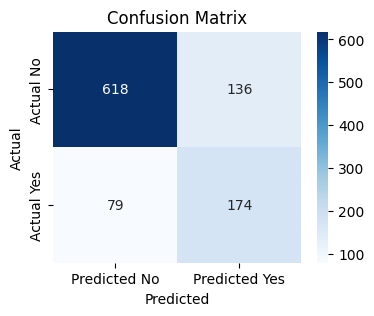

In [7]:
helper.singleModel(param, model_name="xgboost")
helper.printMetrics()
helper.showConfMatrix()

In [8]:
helper.shapConfig()

 95%|=================== | 959/1007 [00:18<00:00]       

In [9]:
features = helper.getTopFeatures(20)

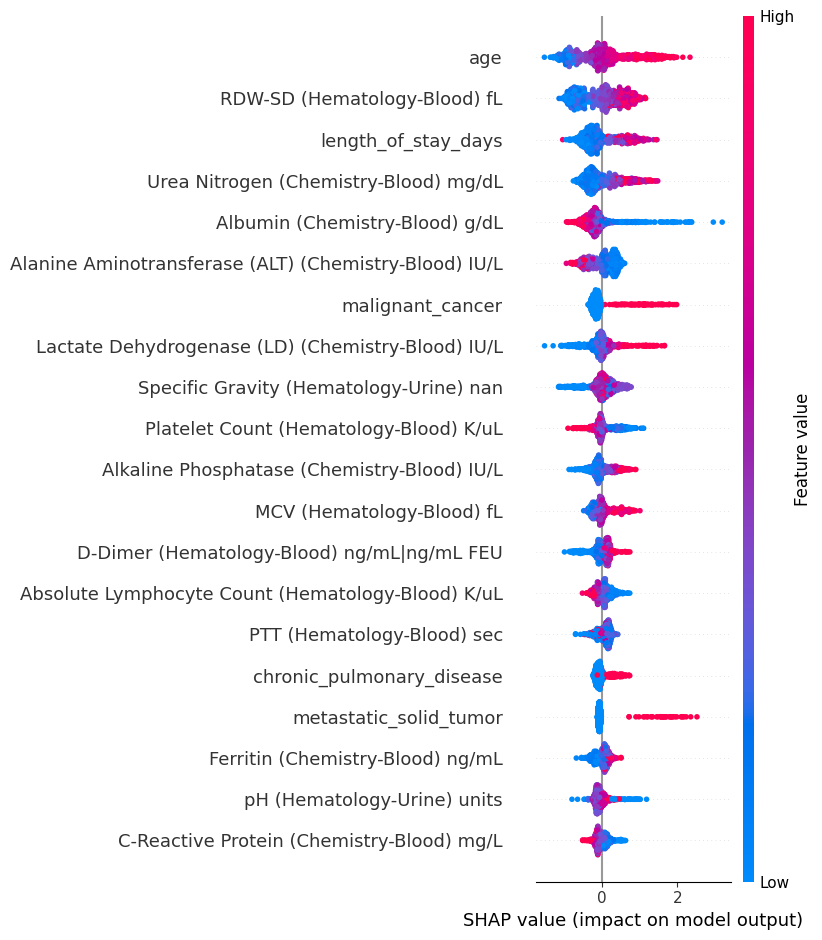

In [10]:
helper.showSummaryShap(verbose=2)

In [11]:
features

['age',
 'RDW-SD_Hematology_Blood_fL',
 'length_of_stay_days',
 'Urea Nitrogen_Chemistry_Blood_mg/dL',
 'Albumin_Chemistry_Blood_g/dL',
 'Alanine Aminotransferase (ALT)_Chemistry_Blood_IU/L',
 'malignant_cancer',
 'Lactate Dehydrogenase (LD)_Chemistry_Blood_IU/L',
 'Specific Gravity_Hematology_Urine_nan',
 'Platelet Count_Hematology_Blood_K/uL',
 'Alkaline Phosphatase_Chemistry_Blood_IU/L',
 'MCV_Hematology_Blood_fL',
 'D-Dimer_Hematology_Blood_ng/mL|ng/mL FEU',
 'Absolute Lymphocyte Count_Hematology_Blood_K/uL',
 'PTT_Hematology_Blood_sec',
 'chronic_pulmonary_disease',
 'metastatic_solid_tumor',
 'Ferritin_Chemistry_Blood_ng/mL',
 'pH_Hematology_Urine_units',
 'C-Reactive Protein_Chemistry_Blood_mg/L']

## Setup Hierarchical Clustering

In [12]:
covid_train['died_after'] = ((covid_train['died'] == 1) & (covid_train['died_in_stay'] == 0)).astype(int)
covid_test['died_after'] = ((covid_test['died'] == 1) & (covid_test['died_in_stay'] == 0)).astype(int)
future_data['died_after'] = ((future_data['died'] == 1) & (future_data['died_in_stay'] == 0)).astype(int)

In [13]:
data_covid = pd.concat([covid_train, covid_test], axis=0)
data_covid = data_covid.sample(frac=1, random_state=42).reset_index(drop=True)

In [14]:
featuresNotConsidered = [x for x in data_covid.columns.tolist() if x not in features]

In [15]:
helper = cluster.SHADEClusterHelper(data=data_covid, featuresNotConsidered=featuresNotConsidered)

## Find best hyperparameters for SHADE

In [16]:
param = {
    "batch_size": [64, 128, 256, 500],
    "clustering_epochs": [100, 150, 200],
    "clustering_lr": {"min": 1e-4, "max": 1e-2},
}

### DBCV

In [17]:
# os.environ["PYTHONWARNINGS"] = "ignore"
# dbcv_df, dbcv_param, dbcv_best = helper.optunaGridSearch(
#     parameters=param, 
#     n_trials=100, 
#     saveStorage=True, 
#     metric="dbcv",
#     restrictMinsizeCluster=2,
#     restrictMaxsizeCluster=80,
#     suffix="death"
# )

In [18]:
dbcv_param = {'batch_size': 64, 'clustering_epochs': 100, 'clustering_lr': 0.00826927781017316}

### DISCO

In [19]:
# os.environ['PYTHONWARNINGS'] = 'ignore'
# disco_df, disco_param, disco_best = helper.optunaGridSearch(
#     parameters=param, 
#     n_trials=100, 
#     saveStorage=True, 
#     metric="disco",
#     restrictMinsizeCluster=2,
#     restrictMaxsizeCluster=80,
#     suffix="death"
# )

In [20]:
disco_param  = {'batch_size': 500, 'clustering_epochs': 150, 'clustering_lr': 0.003985881247310723}

### DSI

In [21]:
# os.environ['PYTHONWARNINGS'] = 'ignore'
# dsi_df, dsi_param, dsi_best = helper.optunaGridSearch(
#     parameters=param, 
#     n_trials=100, 
#     saveStorage=True, 
#     metric="dsi",
#     restrictMinsizeCluster=2,
#     restrictMaxsizeCluster=80,
#     suffix="death"
# )

In [22]:
dsi_param  = {'batch_size': 128, 'clustering_epochs': 200, 'clustering_lr': 0.0006637301014652973}

### Silhouette

In [23]:
# os.environ['PYTHONWARNINGS'] = 'ignore'
# silhouette_df, silhouette_param, silhouette_best = helper.optunaGridSearch(
#     parameters=param, 
#     n_trials=100, 
#     saveStorage=True, 
#     metric="silhouette",
#     restrictMinsizeCluster=2,
#     restrictMaxsizeCluster=80,
#     suffix="death"
# )

In [24]:
silhouette_param = {'batch_size': 64, 'clustering_epochs': 150, 'clustering_lr': 0.009955584849345852}

### Metrics

In [25]:
helper.clustering(
    batch_size=dbcv_param["batch_size"],
    clustering_epochs=dbcv_param["clustering_epochs"],
    clustering_optimizer_params={"lr": dbcv_param["clustering_lr"]},
)
helper.getMetrics()

Autoencoder is not fitted yet, will be pretrained.
Start training with clustering loss.
Epoch: 100%|██████████| 100/100 [00:27<00:00,  3.63it/s]


/Users/gabrielleite/Backup/Mestrado/EnvMestrado/lib/python3.11/site-packages/dbcv/core.py:91: RuntimeWarning: divide by zero encountered in power
  np.power(core_dists, -1.0 / d, out=core_dists)
/Users/gabrielleite/Backup/Mestrado/EnvMestrado/lib/python3.11/site-packages/dbcv/core.py:91: RuntimeWarning: divide by zero encountered in power
  np.power(core_dists, -1.0 / d, out=core_dists)


{'silhouette': -0.329,
 'dbcv': 0.7046197047709787,
 'dsi': np.float64(0.185),
 'disco': np.float64(-0.3512720707508375)}

In [26]:
helper.clustering(
    batch_size=disco_param["batch_size"],
    clustering_epochs=disco_param["clustering_epochs"],
    clustering_optimizer_params={"lr": disco_param["clustering_lr"]},
)
helper.getMetrics()

Autoencoder is not fitted yet, will be pretrained.
Start training with clustering loss.
Epoch: 100%|██████████| 150/150 [00:41<00:00,  3.64it/s]


/Users/gabrielleite/Backup/Mestrado/EnvMestrado/lib/python3.11/site-packages/dbcv/core.py:91: RuntimeWarning: divide by zero encountered in power
  np.power(core_dists, -1.0 / d, out=core_dists)
/Users/gabrielleite/Backup/Mestrado/EnvMestrado/lib/python3.11/site-packages/dbcv/core.py:91: RuntimeWarning: divide by zero encountered in power
  np.power(core_dists, -1.0 / d, out=core_dists)


{'silhouette': 0.377,
 'dbcv': 0.7779425961966556,
 'dsi': np.float64(0.407),
 'disco': np.float64(0.42808353827397855)}

In [27]:
helper.clustering(
    batch_size=dsi_param["batch_size"],
    clustering_epochs=dsi_param["clustering_epochs"],
    clustering_optimizer_params={"lr": dsi_param["clustering_lr"]},
)
helper.getMetrics()

Autoencoder is not fitted yet, will be pretrained.
Start training with clustering loss.
Epoch: 100%|██████████| 200/200 [00:41<00:00,  4.80it/s]


/Users/gabrielleite/Backup/Mestrado/EnvMestrado/lib/python3.11/site-packages/dbcv/core.py:91: RuntimeWarning: divide by zero encountered in power
  np.power(core_dists, -1.0 / d, out=core_dists)
/Users/gabrielleite/Backup/Mestrado/EnvMestrado/lib/python3.11/site-packages/dbcv/core.py:91: RuntimeWarning: divide by zero encountered in power
  np.power(core_dists, -1.0 / d, out=core_dists)
/Users/gabrielleite/Backup/Mestrado/EnvMestrado/lib/python3.11/site-packages/dbcv/core.py:91: RuntimeWarning: divide by zero encountered in power
  np.power(core_dists, -1.0 / d, out=core_dists)
/Users/gabrielleite/Backup/Mestrado/EnvMestrado/lib/python3.11/site-packages/dbcv/core.py:91: RuntimeWarning: divide by zero encountered in power
  np.power(core_dists, -1.0 / d, out=core_dists)


{'silhouette': -0.199,
 'dbcv': -0.6097382244574702,
 'dsi': np.float64(0.283),
 'disco': np.float64(-0.33794195443910546)}

In [28]:
helper.clustering(
    batch_size=silhouette_param["batch_size"],
    clustering_epochs=silhouette_param["clustering_epochs"],
    clustering_optimizer_params={"lr": silhouette_param["clustering_lr"]},
)
helper.getMetrics()

Autoencoder is not fitted yet, will be pretrained.
Start training with clustering loss.
Epoch: 100%|██████████| 150/150 [00:42<00:00,  3.49it/s]


/Users/gabrielleite/Backup/Mestrado/EnvMestrado/lib/python3.11/site-packages/dbcv/core.py:91: RuntimeWarning: divide by zero encountered in power
  np.power(core_dists, -1.0 / d, out=core_dists)
/Users/gabrielleite/Backup/Mestrado/EnvMestrado/lib/python3.11/site-packages/dbcv/core.py:91: RuntimeWarning: divide by zero encountered in power
  np.power(core_dists, -1.0 / d, out=core_dists)


{'silhouette': -0.004,
 'dbcv': 0.665274836858949,
 'dsi': np.float64(0.131),
 'disco': np.float64(-0.030284173457352577)}

## DBCV - Best Result

In [30]:
best_param = disco_param

In [34]:
helper.clustering(
    batch_size=best_param["batch_size"],
    clustering_epochs=best_param["clustering_epochs"],
    clustering_optimizer_params={"lr": best_param["clustering_lr"]},
)

helper.getMetrics()

Autoencoder is not fitted yet, will be pretrained.
Start training with clustering loss.
Epoch: 100%|██████████| 150/150 [00:44<00:00,  3.38it/s]


/Users/gabrielleite/Backup/Mestrado/EnvMestrado/lib/python3.11/site-packages/dbcv/core.py:91: RuntimeWarning: divide by zero encountered in power
  np.power(core_dists, -1.0 / d, out=core_dists)
/Users/gabrielleite/Backup/Mestrado/EnvMestrado/lib/python3.11/site-packages/dbcv/core.py:91: RuntimeWarning: divide by zero encountered in power
  np.power(core_dists, -1.0 / d, out=core_dists)


{'silhouette': 0.377,
 'dbcv': 0.7779425961966556,
 'dsi': np.float64(0.407),
 'disco': np.float64(0.42808353827397855)}

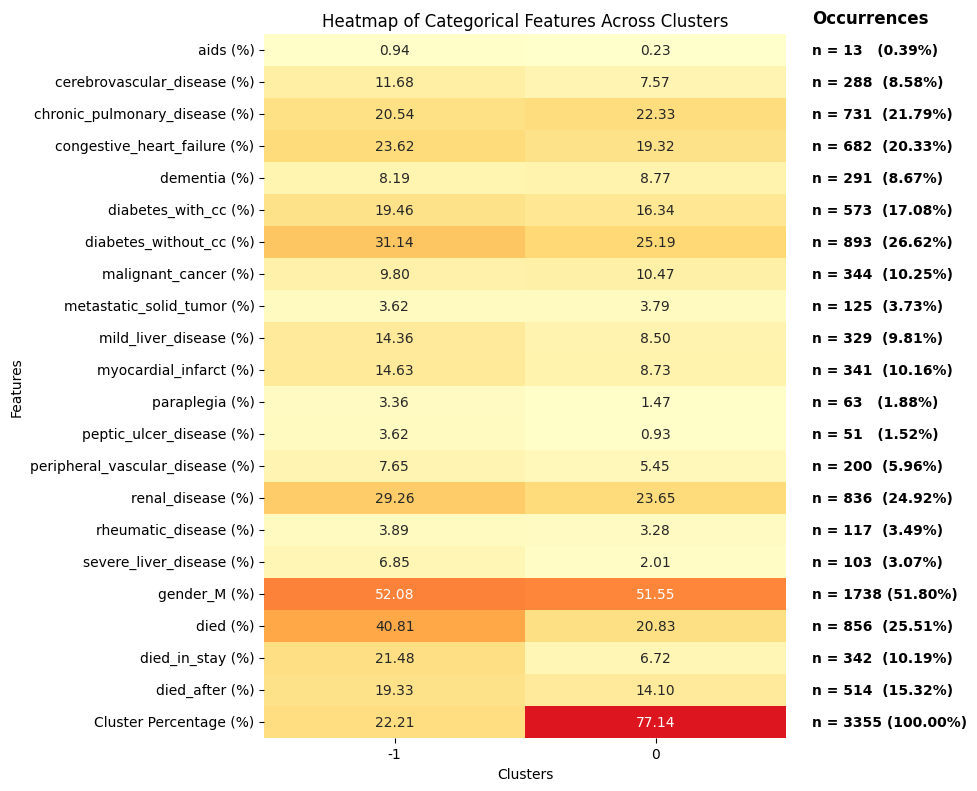

In [36]:
helper.heatmapClustersCategorical(
    figsize=FIGSIZE_CLUSTER_HEATMAP,
    savepath=IMAGES_SAVE_PATH + "shade-death-categorical",
)

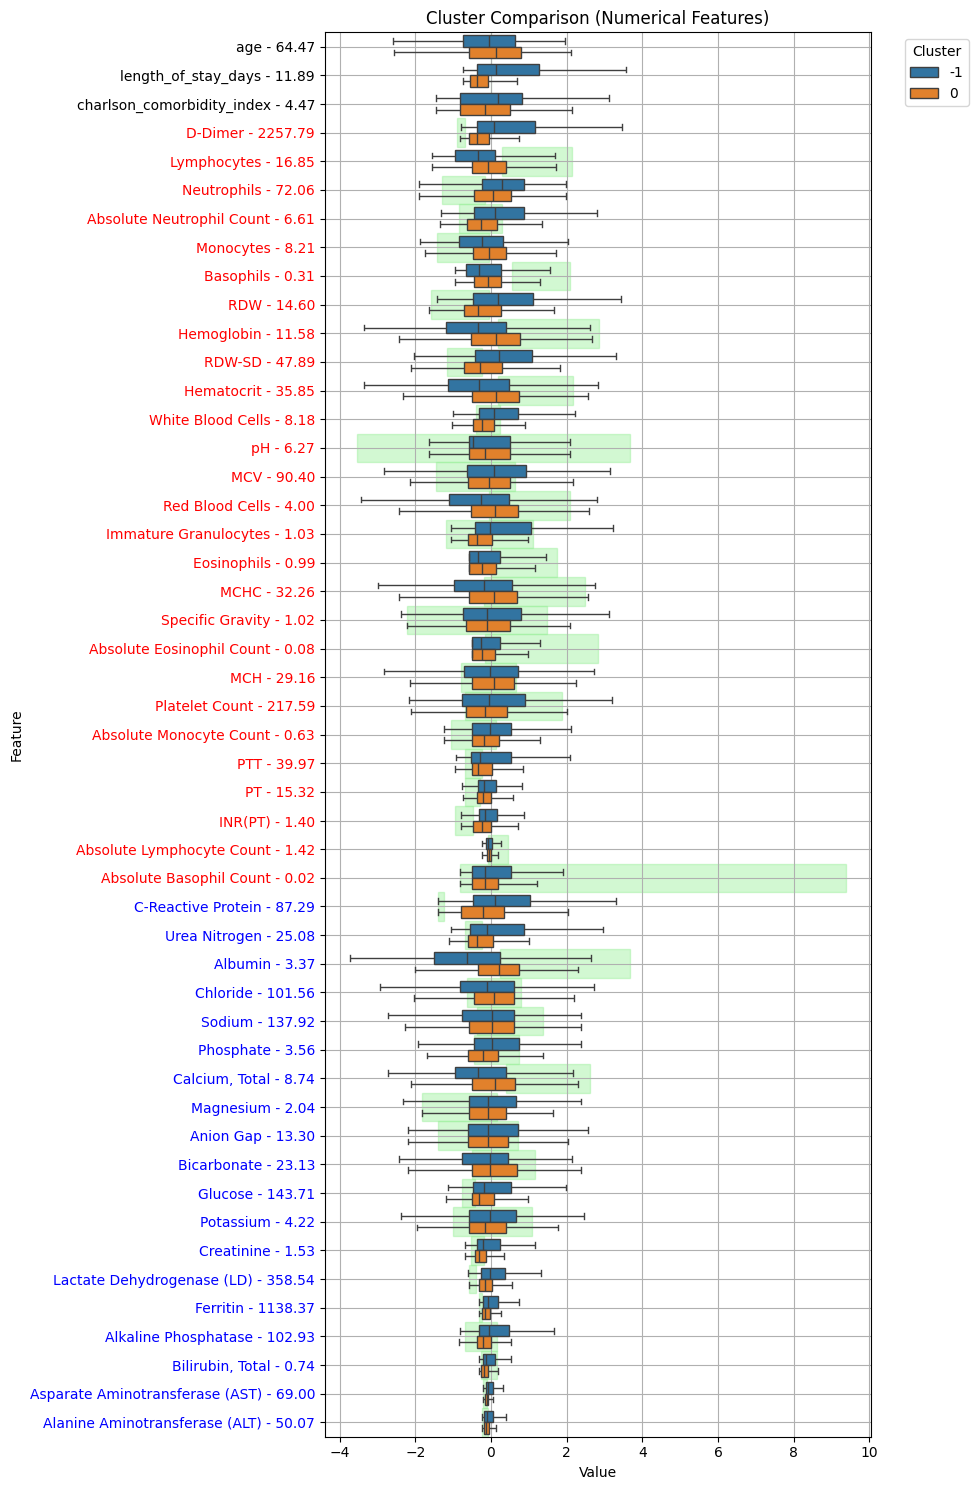

[]

In [37]:
helper.showClusterCompareNumerical(
    scaled="standard",
    topFeatures=-1,
    max_features=-1,
    figsize=(10, 15),
    savepath=IMAGES_SAVE_PATH + "shade-death-numerical"
)

In [38]:
selectedClusters = [-1,0]

In [39]:
helper.setClusteredAutoencoder()

Autoencoder is not fitted yet, will be pretrained.
Start training with clustering loss.
Epoch: 100%|██████████| 100/100 [00:24<00:00,  4.10it/s]


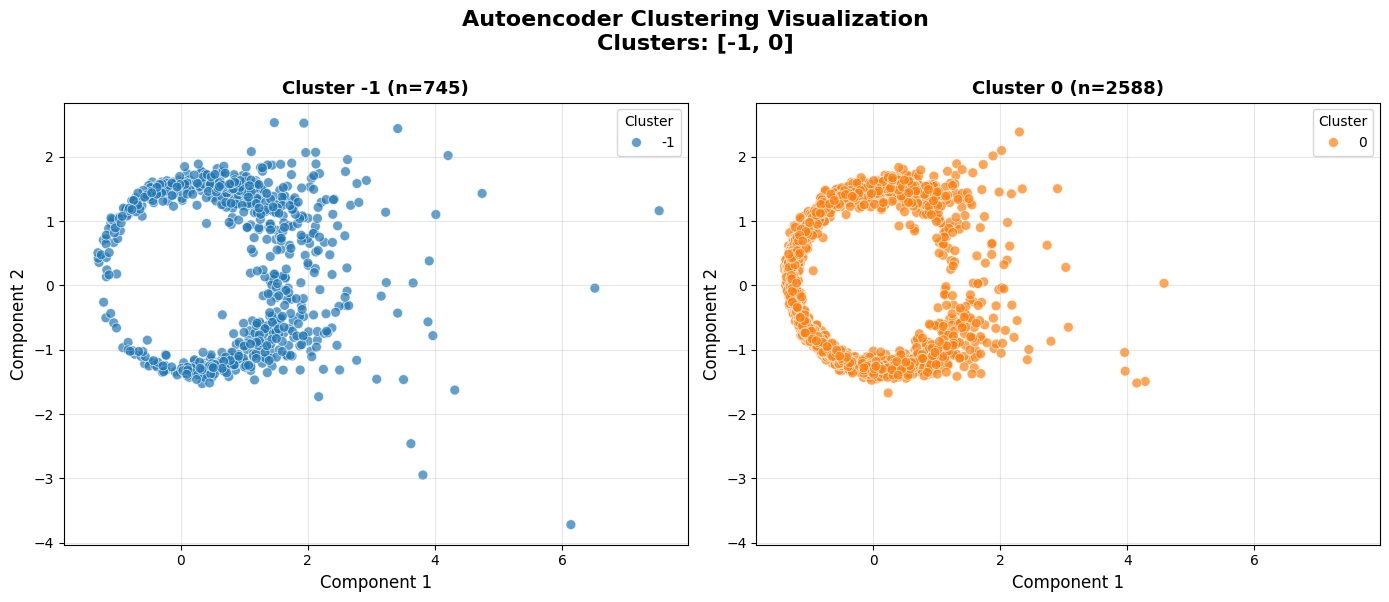

In [40]:
helper.showClusteredAutoencoder(selectedClusters=selectedClusters, savepath=IMAGES_SAVE_PATH + "shade-autoencoder-death")

##### Future data


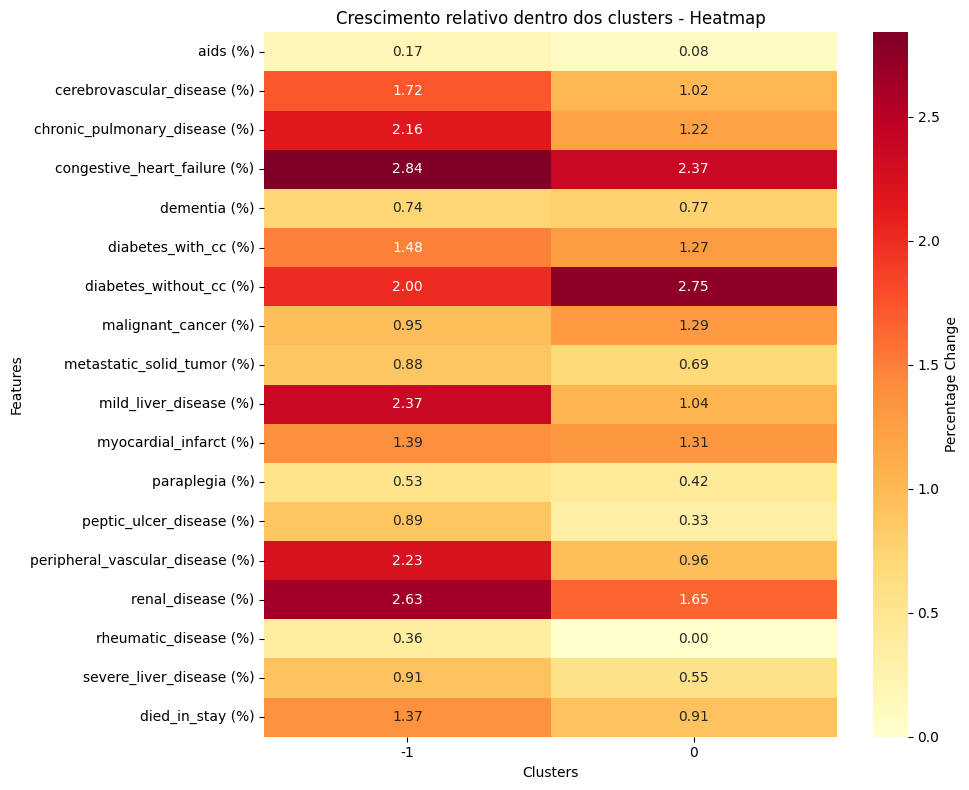

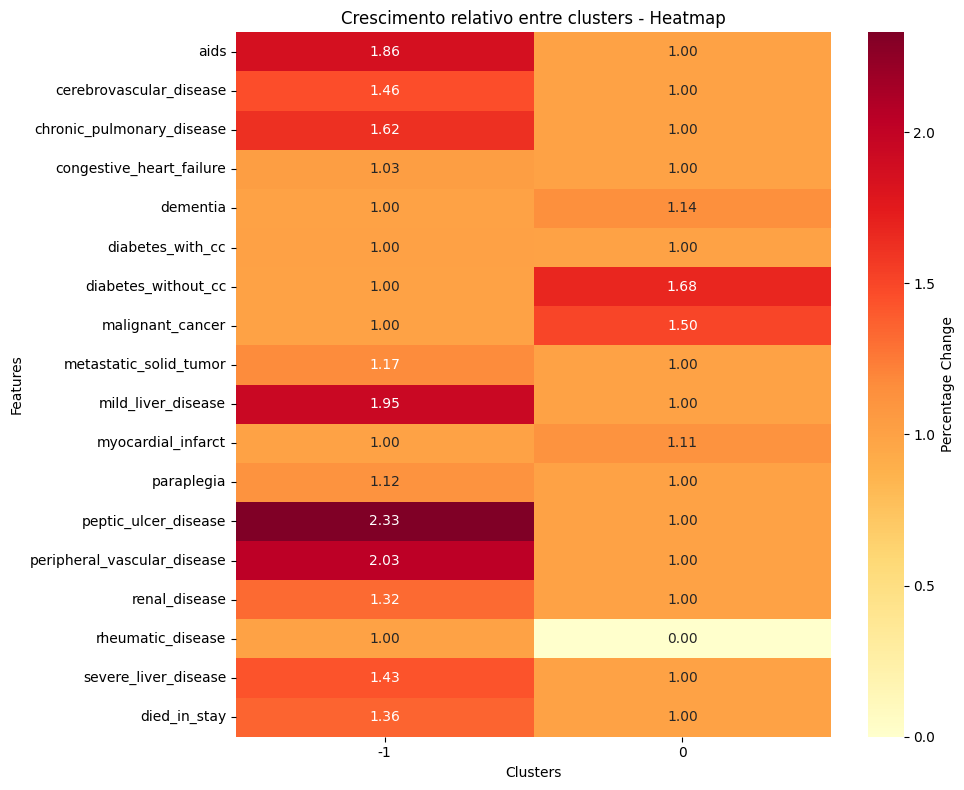

In [41]:
future_helper = fa.FutureAnalysisHelper(helper.clusteredData, future_data)
future_helper.insertClustersInFutureData(onlyFirstAdmission=True)
delta = future_helper.getDeltaClusters(percentage=True, metric="interno")
future_helper.showDeltaHeatmap(
    figsize=FIGSIZE_FUTURE_HEATMAP,
    selectedClusters=selectedClusters,
    savepath=IMAGES_SAVE_PATH + "shade-death-interno",
    metric="interno",
)
delta = future_helper.getDeltaClusters(percentage=True, metric="externo")
future_helper.showDeltaHeatmap(
    figsize=FIGSIZE_FUTURE_HEATMAP,
    selectedClusters=selectedClusters,
    savepath=IMAGES_SAVE_PATH + "shade-death-externo",
    metric="externo",
)

In [42]:
future_helper.getMeanReadmission()

{'Mean readmission Cluster -1': 2.47,
 'Mean readmission Cluster 0': 2.27,
 'Mean readmission Cluster 1': 2.0,
 'Overall Mean readmission': 2.31}

In [43]:
future_helper.getMeanDaysGap()

{'Mean days gap Cluster -1': 133.28,
 'Mean days gap Cluster 0': 126.2,
 'Mean days gap Cluster 1': 23.52,
 'Overall Mean days gap': 127.49}

In [44]:
future_helper.getMortalityRates(onlyFirstAdmission=True)

{'Mortality rate Cluster -1': 0.05,
 'Mortality rate Cluster 0': 0.13,
 'Mortality rate Cluster 1': 0.0,
 'Overall Mortality rate': 0.09}

### Add Log

In [45]:
log_file = "../log.csv"
current_dir = os.getcwd()
log_file_path = os.path.join(current_dir, log_file)

metrics = helper.getMetrics()

# Add line to save log
if os.path.exists(log_file_path):
    with open(log_file_path, 'a') as f:
        f.write(f"Shade, Shap, Comprehensive, {metrics['disco']}, {metrics['dbcv']}, {metrics['dsi']}, {metrics['silhouette']}\n")

/Users/gabrielleite/Backup/Mestrado/EnvMestrado/lib/python3.11/site-packages/dbcv/core.py:91: RuntimeWarning: divide by zero encountered in power
  np.power(core_dists, -1.0 / d, out=core_dists)
/Users/gabrielleite/Backup/Mestrado/EnvMestrado/lib/python3.11/site-packages/dbcv/core.py:91: RuntimeWarning: divide by zero encountered in power
  np.power(core_dists, -1.0 / d, out=core_dists)
